<a href="https://colab.research.google.com/github/KaterinaSor2005/homework_Sorokina332/blob/main/hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

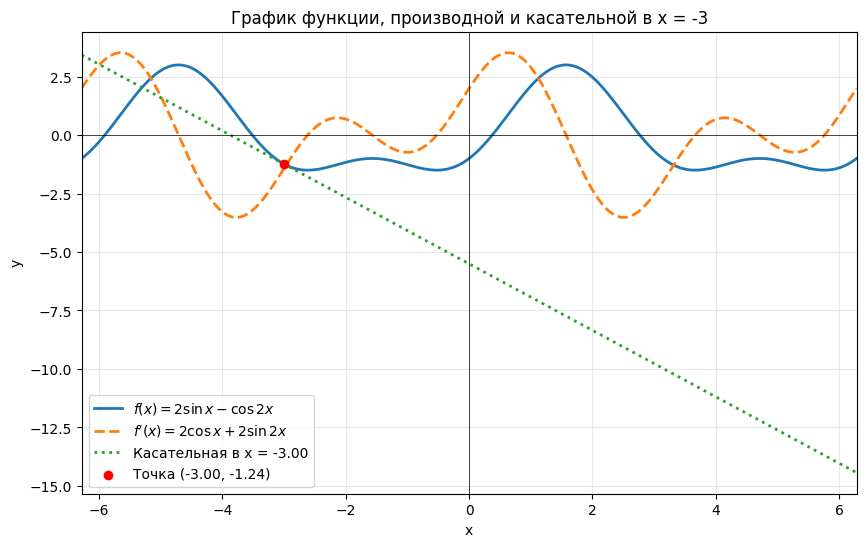

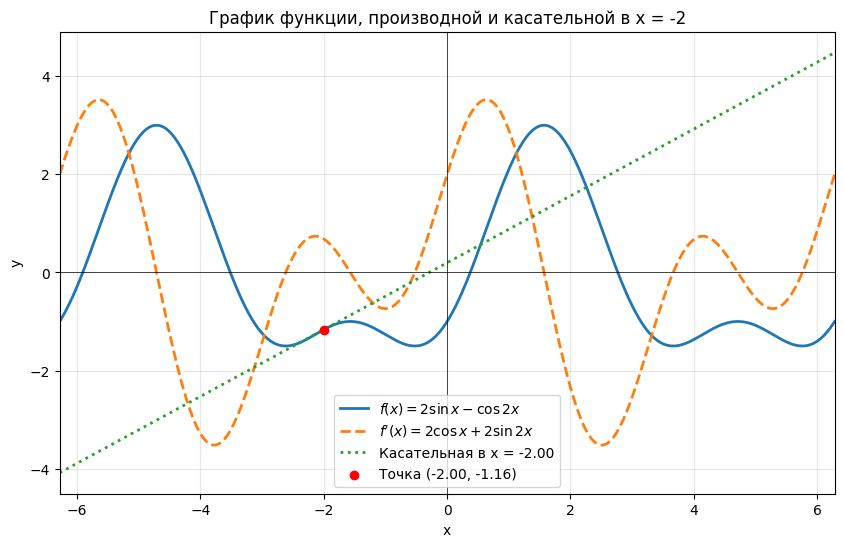

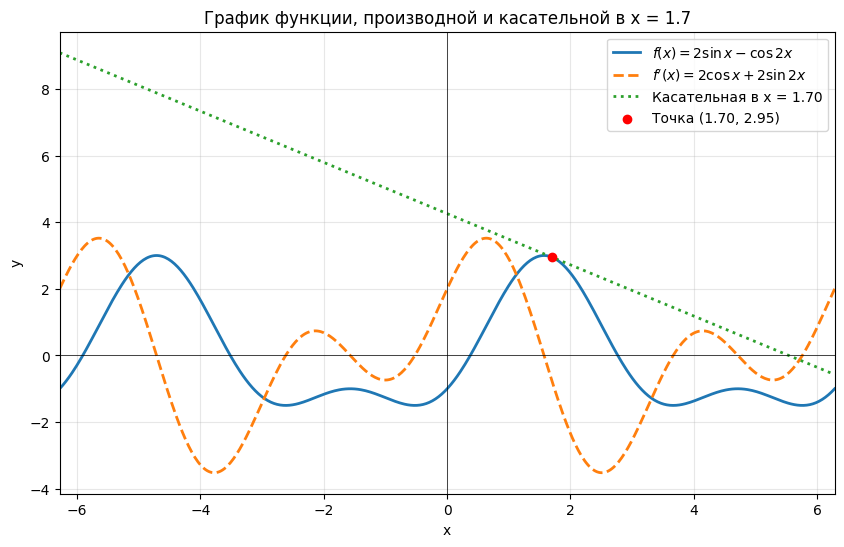

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def beauty_derivative_plot(x0):
    x = np.linspace(-2*np.pi, 2*np.pi, 500)
    f = 2 * np.sin(x) - np.cos(2*x)
    f_prime = 2 * np.cos(x) + 2 * np.sin(2*x)
    f0 = 2 * np.sin(x0) - np.cos(2*x0)
    fp0 = 2 * np.cos(x0) + 2 * np.sin(2*x0)
    tangent = f0 + fp0 * (x - x0)

    plt.figure(figsize=(10, 6))
    plt.plot(x, f, label=r'$f(x) = 2\sin x - \cos 2x$', linewidth=2)
    plt.plot(x, f_prime, '--', label=r"$f'(x) = 2\cos x + 2\sin 2x$", linewidth=2)
    plt.plot(x, tangent, ':', label=f'Касательная в x = {x0:.2f}', linewidth=2)
    plt.scatter([x0], [f0], color='red', zorder=5, label=f'Точка ({x0:.2f}, {f0:.2f})')

    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.grid(alpha=0.3)
    plt.xlim(-2*np.pi, 2*np.pi)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'График функции, производной и касательной в x = {x0}')
    plt.legend()
    plt.show()

# Вызовы
beauty_derivative_plot(-3)
beauty_derivative_plot(-2)
beauty_derivative_plot(1.7)

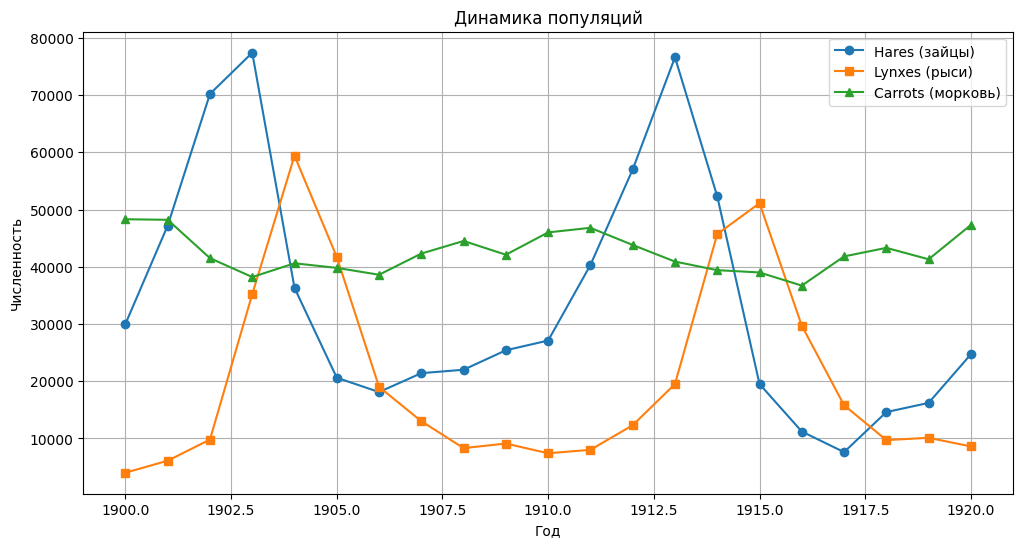

Год макс. численности зайцев: 1903
Год макс. численности рысей: 1904
Год макс. численности моркови: 1900


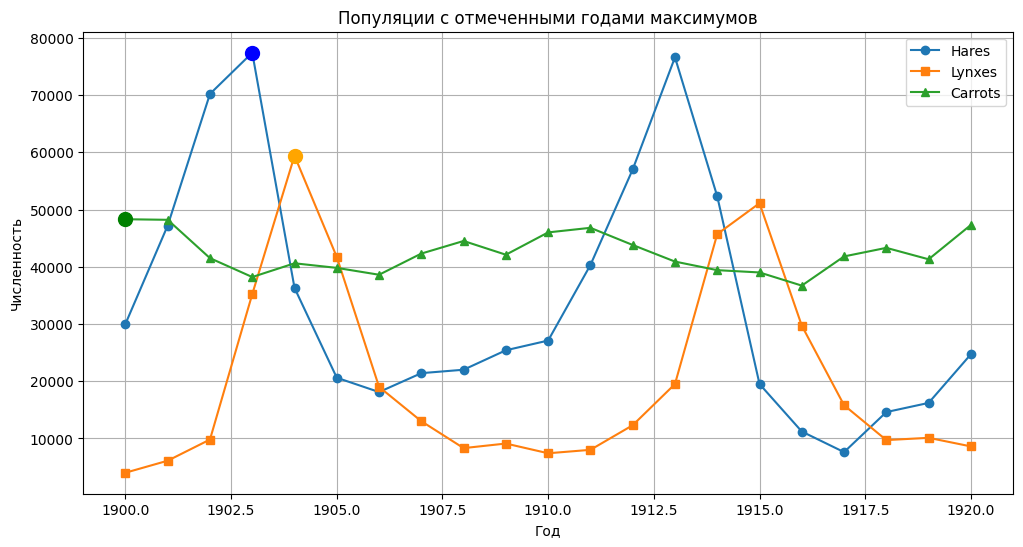

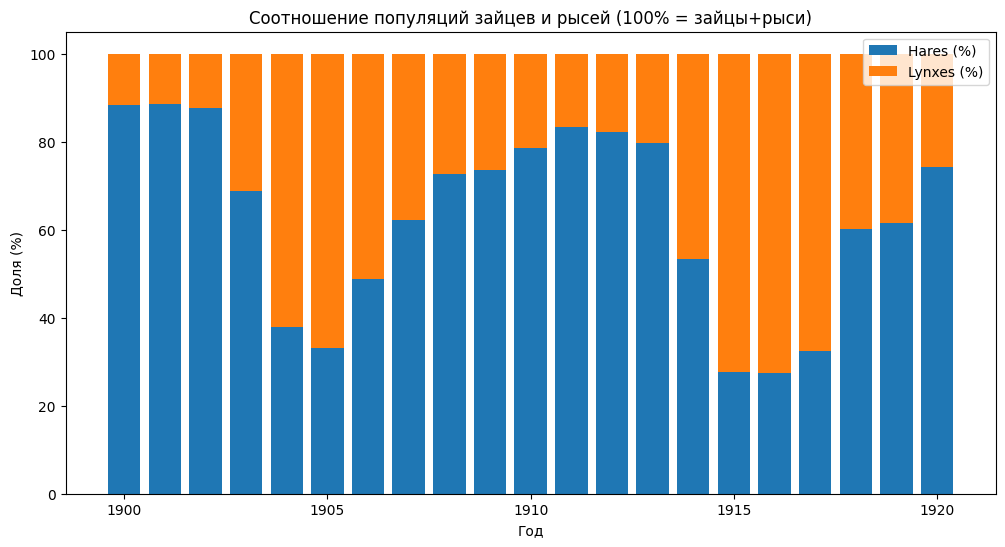

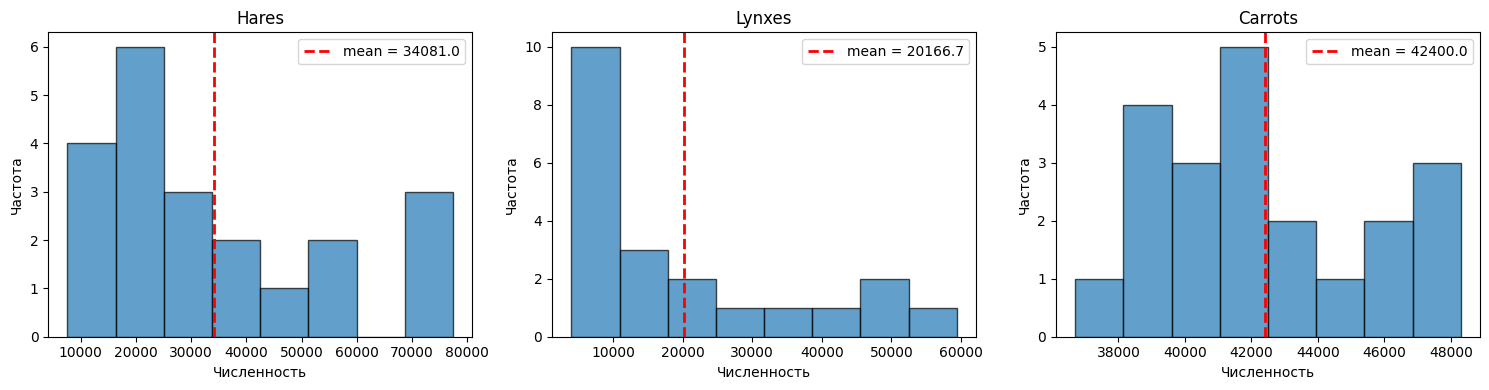

Результат сравнения (H - зайцы больше, L - рыси больше):
['H', 'H', 'H', 'H', 'L', 'L', 'L', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'L', 'L', 'L', 'H', 'H', 'H']


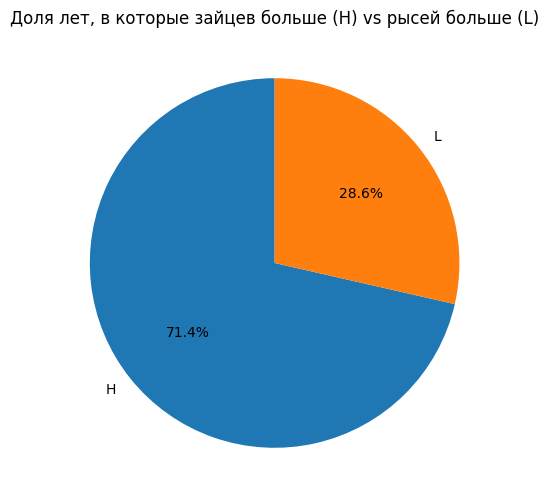

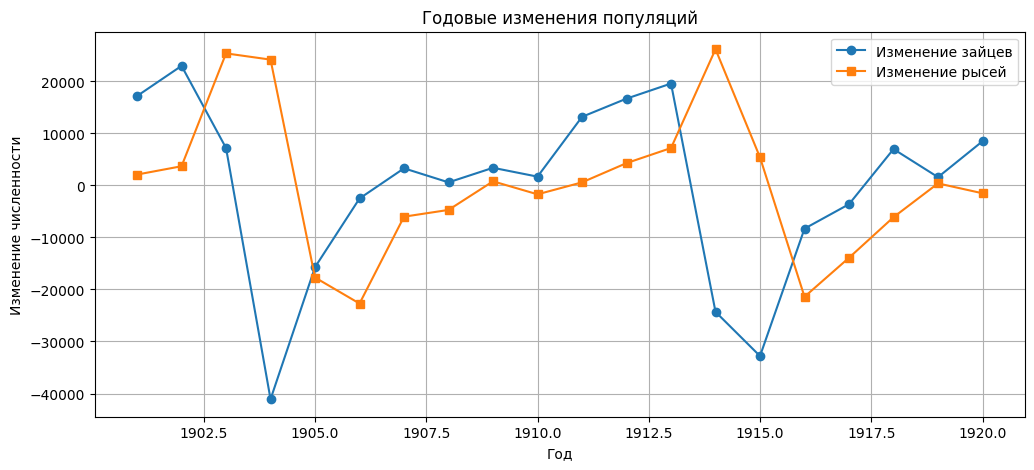

Коэффициент корреляции между изменениями: -0.1780 (p-value = 0.4527)


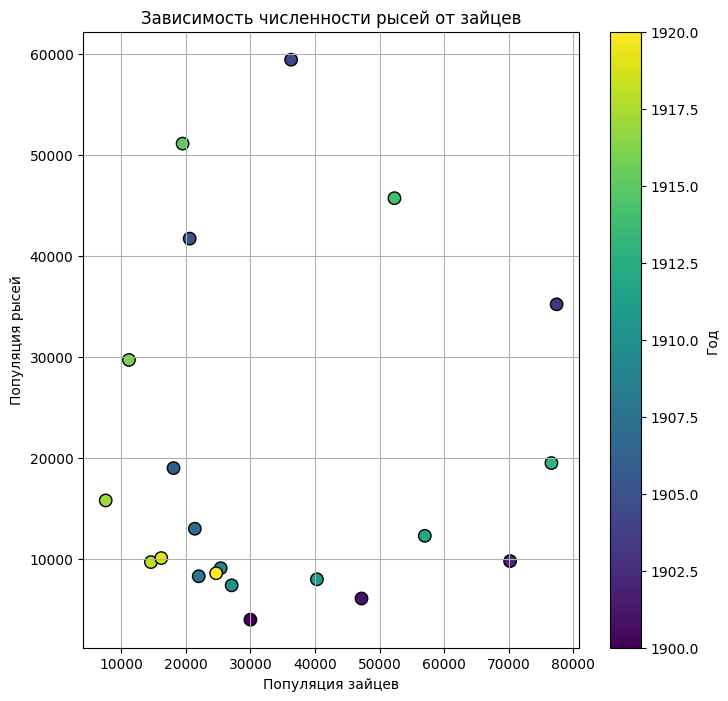


Истинная численность зайцев в 1920: 24700.0
Оценённая (линейная регрессия по остальным годам): 19775.8
Относительная ошибка |оценка - истина|/истина = 0.1994


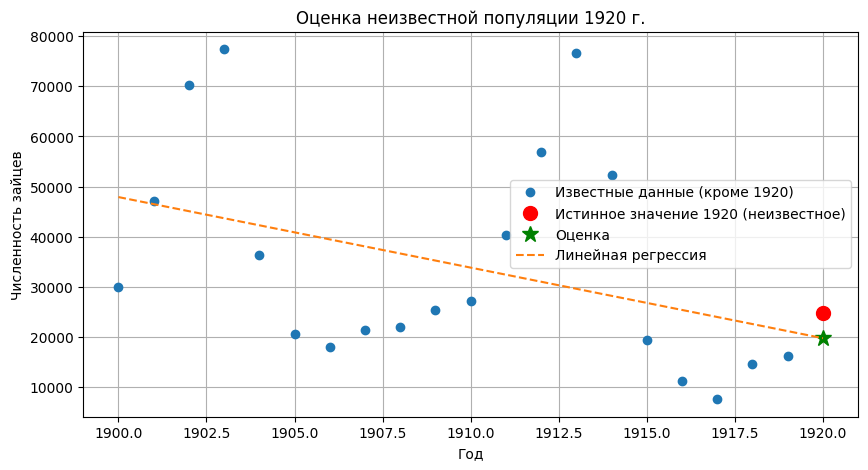

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

url = 'https://raw.githubusercontent.com/TeamLab/machine_learning_from_scratch_with_python/master/code/ch3/populations.txt'
data = np.loadtxt(url)
years = data[:, 0].astype(int)
hares = data[:, 1]
lynxes = data[:, 2]
carrots = data[:, 3]

# График численности каждого вида
plt.figure(figsize=(12, 6))
plt.plot(years, hares, 'o-', label='Hares (зайцы)')
plt.plot(years, lynxes, 's-', label='Lynxes (рыси)')
plt.plot(years, carrots, '^-', label='Carrots (морковь)')
plt.xlabel('Год')
plt.ylabel('Численность')
plt.title('Динамика популяций')
plt.legend()
plt.grid(True)
plt.show()

# Год максимальной численности
max_hares_year = years[np.argmax(hares)]
max_lynxes_year = years[np.argmax(lynxes)]
max_carrots_year = years[np.argmax(carrots)]

print(f"Год макс. численности зайцев: {max_hares_year}")
print(f"Год макс. численности рысей: {max_lynxes_year}")
print(f"Год макс. численности моркови: {max_carrots_year}")

plt.figure(figsize=(12, 6))
plt.plot(years, hares, 'o-', label='Hares')
plt.plot(years, lynxes, 's-', label='Lynxes')
plt.plot(years, carrots, '^-', label='Carrots')
plt.scatter([max_hares_year], [hares[years==max_hares_year][0]], color='blue', s=100, zorder=5)
plt.scatter([max_lynxes_year], [lynxes[years==max_lynxes_year][0]], color='orange', s=100, zorder=5)
plt.scatter([max_carrots_year], [carrots[years==max_carrots_year][0]], color='green', s=100, zorder=5)
plt.xlabel('Год')
plt.ylabel('Численность')
plt.title('Популяции с отмеченными годами максимумов')
plt.legend()
plt.grid(True)
plt.show()

# Соотношения зайцев и рысей
total_hl = hares + lynxes
hare_ratio = hares / total_hl * 100
lynx_ratio = lynxes / total_hl * 100

plt.figure(figsize=(12, 6))
plt.bar(years, hare_ratio, label='Hares (%)', width=0.8)
plt.bar(years, lynx_ratio, bottom=hare_ratio, label='Lynxes (%)', width=0.8)
plt.xlabel('Год')
plt.ylabel('Доля (%)')
plt.title('Соотношение популяций зайцев и рысей (100% = зайцы+рыси)')
plt.legend()
plt.show()

# Гистограммы численности
species = [hares, lynxes, carrots]
names = ['Hares', 'Lynxes', 'Carrots']
means = [np.mean(s) for s in species]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, s, name, mean in zip(axes, species, names, means):
    ax.hist(s, bins=8, edgecolor='black', alpha=0.7)
    ax.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'mean = {mean:.1f}')
    ax.set_title(name)
    ax.set_xlabel('Численность')
    ax.set_ylabel('Частота')
    ax.legend()
plt.tight_layout()
plt.show()

# Сравнение численностей
winner = np.where(hares > lynxes, 'H', 'L')
print("Результат сравнения (H - зайцы больше, L - рыси больше):")
print(winner.tolist())

unique, counts = np.unique(winner, return_counts=True)
plt.figure(figsize=(6,6))
plt.pie(counts, labels=unique, autopct='%1.1f%%', startangle=90)
plt.title('Доля лет, в которые зайцев больше (H) vs рысей больше (L)')
plt.show()

# Изменение численности и корреляция
hare_change = np.diff(hares)
lynx_change = np.diff(lynxes)
years_change = years[1:]

plt.figure(figsize=(12, 5))
plt.plot(years_change, hare_change, 'o-', label='Изменение зайцев')
plt.plot(years_change, lynx_change, 's-', label='Изменение рысей')
plt.xlabel('Год')
plt.ylabel('Изменение численности')
plt.title('Годовые изменения популяций')
plt.legend()
plt.grid(True)
plt.show()

corr, p_value = pearsonr(hare_change, lynx_change)
print(f"Коэффициент корреляции между изменениями: {corr:.4f} (p-value = {p_value:.4f})")

plt.figure(figsize=(8, 8))
plt.scatter(hares, lynxes, c=years, cmap='viridis', s=80, edgecolors='k')
plt.colorbar(label='Год')
plt.xlabel('Популяция зайцев')
plt.ylabel('Популяция рысей')
plt.title('Зависимость численности рысей от зайцев')
plt.grid(True)
plt.show()

# Оценка неизвестной популяции
idx_1920 = np.where(years == 1920)[0][0]
true_1920 = hares[idx_1920]
years_train = np.delete(years, idx_1920)
hares_train = np.delete(hares, idx_1920)

# Линейная регрессия
coeffs = np.polyfit(years_train, hares_train, 1)
poly = np.poly1d(coeffs)
estimated_1920 = poly(1920)

error_ratio = abs(estimated_1920 - true_1920) / true_1920
print(f"\nИстинная численность зайцев в 1920: {true_1920}")
print(f"Оценённая (линейная регрессия по остальным годам): {estimated_1920:.1f}")
print(f"Относительная ошибка |оценка - истина|/истина = {error_ratio:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(years_train, hares_train, 'o', label='Известные данные (кроме 1920)')
plt.plot(1920, true_1920, 'ro', markersize=10, label='Истинное значение 1920 (неизвестное)')
plt.plot(1920, estimated_1920, 'g*', markersize=12, label='Оценка')
plt.plot(years, poly(years), '--', label='Линейная регрессия')
plt.xlabel('Год')
plt.ylabel('Численность зайцев')
plt.title('Оценка неизвестной популяции 1920 г.')
plt.legend()
plt.grid(True)
plt.show()